# Implementing Forward Propagation with numpy

In [ ]:
#!pip install matplotlib
import matplotlib.pyplot as plt
import numpy as np
import time
print("All imported")


## This is what we want to implement 
We want to classify the green and blue points (blue points beeing the positive class). It’s a binary classification problem with a nonlinear decision boundary, so linear regression will not be able to separate the classes properly.

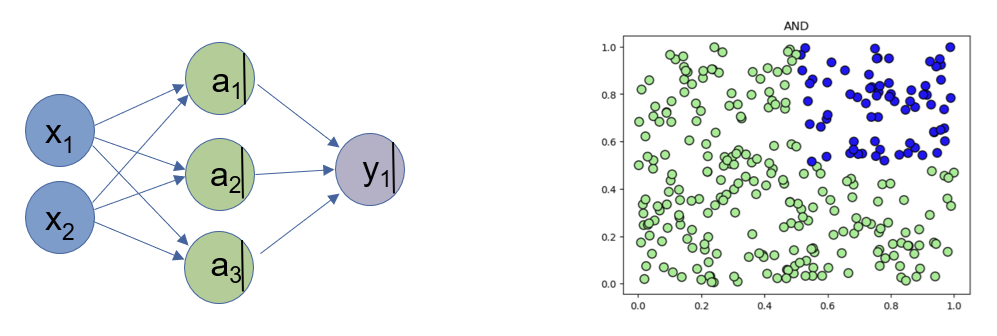

## A common superclass called "Layer" 

In [ ]:
class Layer:
    """
    An identity Layer to be the base of inheritance
    """
    def __init__(self):
        pass
    
    def forward(self, input):
        # identity, same output as input
        return input

## A sigmoid Layer
In most frameworks the activation function is part of the layer that does the linear combination. For didatic reasons we implement this is a seperate Layer. Basically it appiles the sigmoid function $\sigma(x)= \frac{1}{1+e^{-x}}$ 

In [ ]:
class Sigmoid(Layer):
    def __init__(self):
        pass
    
    def forward(self, input):
        """Apply elementwise sigmoid to [input_units] vector"""
        return 1/(1 + np.exp(-input))
    
    def __str__(self):
        "Sigmoid()"

In [ ]:
#test sigmoid Layer
np.set_printoptions(precision=5, suppress=True) # no scientific notation
x = np.array([-10,-1,0,1,10])
Sigmoid().forward(x)


In [ ]:
# Plot it to get an impression of the sigmoid function
x = np.arange(-10,10,0.4)
y = Sigmoid().forward(x)
import matplotlib.pyplot as plt
plt.plot(x,y)

## A dense Layer
A dense layer is defined by the size of the input vector and the output vector. Inside the dense layer, we store weights and biases, which must be initialized.

We define the forward function that is executed during the forward pass.

In [ ]:
class Dense(Layer):
    """
    A dense layer f(x) = <x*W> + b
    """
    def __init__(self, input_units, output_units):
        # initialize weights with small random numbers. We use normal distribution, 
        self.weights = np.random.randn(output_units, input_units)*0.01
        self.biases = np.zeros(output_units)
        
    def forward(self,input):
        return self.weights.dot(input)+self.biases;

In [ ]:
x = np.array([0.8,0.8])
d = Dense(2,3)
d.forward(x)


## Create Network code for single Training examples

Look at the example network structure at the left. 
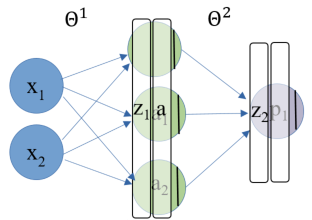
* We realize it in a hardcoded way and initialize all layers.
* We then set weights that we created in the ML lecture.
* then we need to implement "predict", which does the complete forward path
* We implement a __str__ function to output the network structure


In [ ]:
class Network:
    def __init__(self): 
        # create all layers in attibutes d/s/o
        self.d = Dense(2,3)
        self.s = Sigmoid()
        self.o = Dense(3,1)
        
        # Assign weights and Biases (taken from ML Course last year)
        self.d.weights = np.array([[10,0],[0,10],[0,0]])     # Weights first Layer (outputunits x inputunits)
        self.d.biases = np.array([-5,-5,0])                  # Biasvalues first layer (outputunits)
        self.o.weights = np.array([[10, 10, 0]])             # Weights second Layer (inputunits x outputunits)
        self.o.biases = np.array([-18])                      # Biasvalues second layer (outputunits)

    def predict(self, input):
        z1 = self.d.forward(input); 
        a = self.s.forward(z1);
        z2 = self.o.forward(a);
        y = self.s.forward(z2);
        return y

    def __str__(self):
        text = "Network:\n"
        text +=  f"Layer1 weights:{self.d.weights.tolist()}\n"
        text +=  f"Layer1 biases:{self.d.biases}\n"
        text +=  f"Layer2 weights:{self.o.weights}\n"
        text +=  f"Layer2 biases:{self.o.biases}\n"
        return text

net = Network()
print(net)


## Test by making predictions

In [ ]:
np.set_printoptions(suppress=False)

#instantiate the network and make a prediction
#input = np.array([0.8,0.8]) # 300 300 0
input = np.array([0.48,0.3]) 

net.predict(input)

In [ ]:
# Vizualize decision border by predicting many points
def vizualizeDecisionBorder(net):
   samples = 20000
   X = np.random.rand(samples,2)
   p = np.array([(net.predict(X[i])[0]) for i in range(samples)])
   ptrue=(p>0.5)*1
   colorvec = np.array(["green","blue"])[ptrue]
   plt.scatter(X[:,0],X[:,1],c=colorvec,s=1)

vizualizeDecisionBorder(net)

❓**Question:** The weights that wre are using are classifying some points properly but they are not perfect. How do we make obvious that they are not good ?

<br><br><br><br><br><br><br>

## A network with a loss function (log loss)

![](attachment:grafik-X.png)
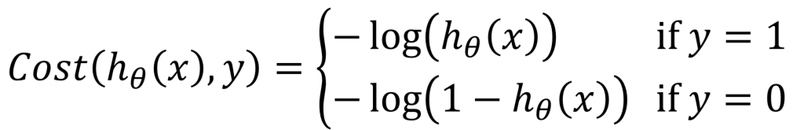

In [ ]:
class Network:
    def __init__(self): 
        self.d = Dense(2,3)
        self.s = Sigmoid()
        self.o = Dense(3,1)

        # these weights will make a more accurate prediction compared to the example above 
        self.d.weights = np.array([[10,0],[0,10],[0,0]]) # inputunits x outputunits
        self.d.biases = np.array([-5,-5,0])              # outputunits
        self.o.weights = np.array([[10, 10, 0]])             # inputunits x outputunits
        self.o.biases = np.array([-18])                      # outputunits

    # --- NEW CODE HERE
    
    def loss(self, y, pred):
        return y*(-np.log(pred))+(1-y)*(-np.log(1-pred))
    
    # --- NEW CODE HERE

    def predict(self, input):
        z1 = self.d.forward(input)
        a = self.s.forward(z1)
        z2 = self.o.forward(a)
        y = self.s.forward(z2)
        return y
    
    def __str__(self):
        text = "Network:\n"
        text +=  f"Layer1 weights:{self.d.weights.tolist()}\n"
        text +=  f"Layer1 biases:{self.d.biases}\n"
        text +=  f"Layer2 weights:{self.o.weights}\n"
        text +=  f"Layer2 biases:{self.o.biases}\n"
        return text
    
dir(Network) # shows all functions, including the newly added function 


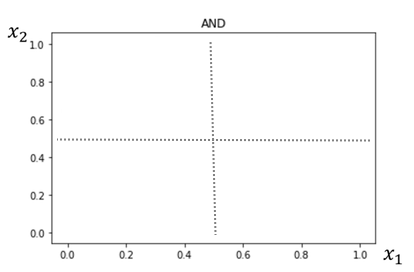

## Calculate prediction and loss for some points



In [ ]:
x1 = np.array([0.6,0.4]) # negative class
x2 = np.array([0.8,0.8]) # positive class
net = Network()

p1 = net.predict(x1)
p2 = net.predict(x2)

loss1 = net.loss(0,p1)
loss2 = net.loss(1,p2)

print(f"negative point - p={p1} prediction={p1>0.5} loss={loss1}")
print(f"posivive point - p={p2} prediction={p2>0.5} loss={loss2}")
print(f"average loss = {(loss1+loss2)/2}")

❓ **Question:** How good is this result ? What is the maximum possible value ? 

## Now change the weights and recalculate the loss

In [ ]:
net.d.weights = np.array([[100,0],[0,100],[0,0]]) # inputunits x outputunits
net.d.biases = np.array([-50,-50,0])              # outputunits
print(net)

In [ ]:
# Make predictions and calculate the loss
p1 = net.predict(x1)
p2 = net.predict(x2)

loss1 = net.loss(0,p1)
loss2 = net.loss(1,p2)

print(f"negative point - p={p1} prediction={p1>0.5} loss={loss1}")
print(f"posivive point - p={p2} prediction={p2>0.5} loss={loss2}")
print(f"average loss = {(loss1+loss2)/2}")

In [ ]:
# The loss was much lower, lets get a visual idea of the effect
vizualizeDecisionBorder(net)

## Inference Speedtest

Here we do a speedtest with this implementation because later we will have a improved version

In [ ]:
samples = 300000
net = Network()
X = np.random.rand(samples,2) 
startTime = time.time()
print(X.shape)
for x in X:
    p = net.predict(x)
endTime = time.time()
print(f"Used Time: {endTime-startTime} s")

🎯Conclusion: Inference is fast, however if we do a lot of samples recurring execution takes a reasonable time!